# **TikTok Project**
**Course 4 - Regression Analysis: Simplify complex data relationships**

In [723]:
import numpy as np
import pandas as pd
import platform
import statsmodels
print('Python version: ', platform.python_version())
print('numpy version: ', np.__version__)
print('pandas version: ', pd.__version__)
print('statsmodels version: ', statsmodels.__version__)

Python version:  3.11.4
numpy version:  1.24.4
pandas version:  2.0.3
statsmodels version:  0.14.0


You are a data professional at TikTok. The data team is working towards building a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

The TikTok team has reviewed the results of the hypothesis testing. TikTok’s Operations Lead, Maika Abadi, is interested in how different variables are associated with whether a user is verified. Earlier, the data team observed that if a user is verified, they are much more likely to post opinions. Now, the data team has decided to explore how to predict verified status to help them understand how video characteristics relate to verified users. Therefore, you have been asked to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 4 End-of-course project: Regression modeling**


In this activity, you will build a logistic regression model in Python. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

<br/>

**The purpose** of this project is to demostrate knowledge of EDA and regression models.

**The goal** is to build a logistic regression model and evaluate the model.
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a logistic regression model?
* EDA helps data professionals familiarize themselves with the data, determine the independent variable and dependent variable that should be used for the analysis, as well as the type of data and whether it needs to be converted to the appropriate type.

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?
1/ read_csv, .head(), .describe(), isna(), dropna, dtype(), and atype() for EDA. For building the model, I used scikit-learn to split the data into training and testing sets, fit the classifiers, and evaluate the model's performance based on outcome evaluation metrics, including precision, recall, and accuracy, along with visualizing it using confusion matrices.
**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?
* -Model Performance: The logistic regression model achieved an accuracy of 65%. Although the precision for predicting unverified accounts was slightly lower at 61%, the model's recall of 85% for unverified accounts was higher, indicating that the model was able to catch 85% of the unverified accounts that were actually unverified.

- Video Duration: The model's coefficient uncovered that video duration (video_duration_sec) has the strongest positive association with verified status. That means for every additional second in video duration, the log odds of the account being verified increase by 0.009. 

- Low impact of Engagement Metrics: Other features, such as view counts, share counts, download count, and comment counts, yield small coefficients. This indicates that they have a minimal association with the account verification status in this model.


* What business recommendations do you propose based on the models built?
* Based on the model’s insight, a business recommendation would be to further analyze the relationship between video duration and account status by gathering more data to make sure that the findings are robust. Also, tailor the content strategies to focus on producing longer videos, as it seems to be a strong indicator of a verified account.

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.


# **Build a regression model**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and loading**
Import the data and packages that you've learned are needed for building regression models.

In [724]:
# Import packages for data manipulation
import pandas as np
import numpy as np


# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns 


# Import packages for data preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import sklearn.metrics as matrics
from sklearn.metrics import classification_report


# Import packages for data modeling
from sklearn.model_selection import train_test_split


Load the TikTok dataset.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [725]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a logistic regression model?


The purpose of performing EDA before constructing a multiple linear regression is for data professionals to familiarize themselves with the data, conduct a thorough analysis of the relationships between variabales, and assess variable assumptions such as linearity and independent observation before the model is built. 

### **Task 2a. Explore data with EDA**

Analyze the data and check for and handle missing values and duplicates.

Inspect the first five rows of the dataframe.

In [726]:
# Display first few rows

data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [727]:
# Get number of rows and columns

data.shape

(19382, 12)

Get the data types of the columns.

In [728]:
# Get data types of columns

data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [729]:
# Get basic information
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


The average of verified account is 93.6% 

Generate basic descriptive statistics about the dataset.

In [730]:
# Generate basic descriptive stats
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [731]:
# Check for missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [732]:
# Drop rows with missing values
data = data.dropna(axis=0).reset_index(drop=True)

In [733]:
# Display first few rows after handling missing values
data.isna().sum()

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64

Check for and handle duplicates.

In [734]:
# Check for duplicates
data.duplicated().sum()

0

It seems there is no duplication. 

Check for and handle outliers.

<Axes: xlabel='video_duration_sec'>

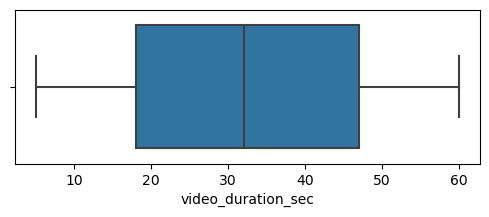

In [735]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(6,2))
sns.boxplot(x = data['video_duration_sec'])


<Axes: xlabel='video_view_count'>

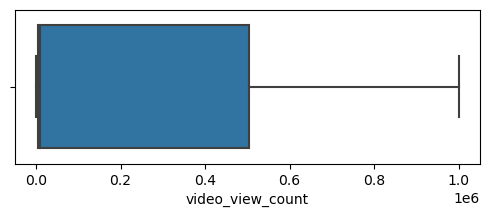

In [736]:
# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(6,2))
sns.boxplot(x = data['video_view_count'])

<Axes: xlabel='video_like_count'>

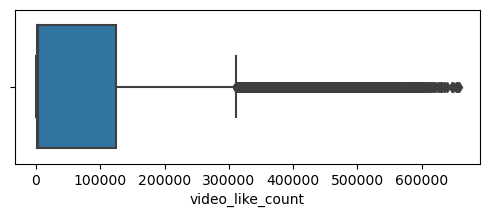

In [737]:
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(6,2))
sns.boxplot(x=data['video_like_count'])

<Axes: xlabel='video_comment_count'>

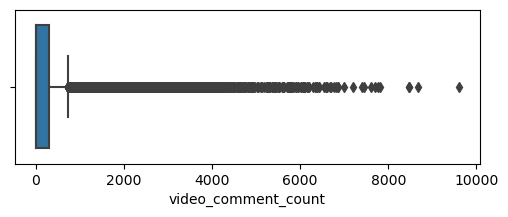

In [738]:
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(6,2))
sns.boxplot(x=data['video_comment_count'])



In [739]:
# Check for and handle outliers for video_like_count
Q1 = data['video_like_count'].quantile(0.25)
Q3 = data['video_like_count'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

lower_limit = Q1 - 1.5 * IQR

data.loc[data['video_like_count'] > upper_limit, 'video_like_count'] = upper_limit




Check class balance of the target variable. Remember, the goal is to predict whether the user of a given post is verified or unverified.

In [740]:
# Check class balance
c = data['verified_status'].value_counts()
count_verified = 1200/(1200 + 17884)
count_unverified = 17884/(1200 + 17884)
print(c)
print(f"verified count: {count_verified}")
print(f"unverified count: {count_unverified}")

verified_status
not verified    17884
verified         1200
Name: count, dtype: int64
verified count: 0.06287989939216097
unverified count: 0.937120100607839


Approximately 93.7% of the dataset represents videos posted by unverified accounts and 6.2% represents videos posted by verified accounts. So the outcome variable is not very balanced.

Use resampling to create class balance in the outcome variable, if needed.

In [741]:
# Use resampling to create class balance in the outcome variable, if needed

# Identify data points from majority and minority classes
from sklearn.utils import resample
majority = data[data['verified_status'] == 'not verified']
minority = data[data['verified_status'] == 'verified']


# Upsample the minority class (which is "verified")

minority_upsampled = resample(minority, replace =True, n_samples=len(majority), random_state=0)

# Combine majority class with upsampled minority class
data_upsampled = pd.concat([majority, minority_upsampled]).reset_index(drop=True)

# Display new class counts
data_upsampled['verified_status'].value_counts()


verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

Get the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.



In [742]:
# Get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
data_upsampled.groupby('verified_status')['video_transcription_text'].apply(lambda x: x.str.len().mean())


verified_status
not verified    89.401141
verified        84.569559
Name: video_transcription_text, dtype: float64

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [743]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data_upsampled['text_length'] = data_upsampled['video_transcription_text'].str.len()

In [744]:
# Display first few rows of dataframe after adding new column
data_upsampled.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


In [745]:
# Display first few rows of dataframe after adding new column
data_upsampled.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

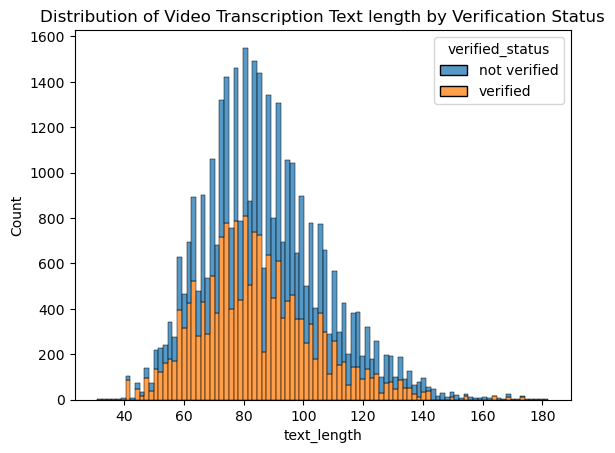

In [746]:
# Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Create two histograms in one plot
sns.histplot(x='text_length', hue='verified_status', data=data_upsampled, multiple='stack')
plt.title('Distribution of Video Transcription Text length by Verification Status')
plt.show()


### **Task 2b. Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

In [747]:
# Code a correlation matrix to help determine most correlated variables
correlation_matrix = data_upsampled.corr(numeric_only=True)
correlation_matrix


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
#,1.000000,-0.000853,-0.011729,-0.697007,-0.626385,-0.504015,-0.487096,-0.413799,-0.193677
video_id,-0.000853,1.000000,0.011859,0.002554,0.005993,0.010515,0.008753,0.013983,-0.007083
video_duration_sec,-0.011729,0.011859,1.000000,0.013589,0.004494,0.002206,0.003989,-0.004586,-0.002981
video_view_count,-0.697007,0.002554,0.013589,1.000000,0.856937,0.711313,0.690048,0.583485,0.244693
video_like_count,-0.626385,0.005993,0.004494,0.856937,1.000000,0.832146,0.805543,0.686647,0.216693
video_share_count,-0.504015,0.010515,0.002206,0.711313,0.832146,1.000000,0.710117,0.620182,0.171651
video_download_count,-0.487096,0.008753,0.003989,0.690048,0.805543,0.710117,1.000000,0.857679,0.173396
video_comment_count,-0.413799,0.013983,-0.004586,0.583485,0.686647,0.620182,0.857679,1.000000,0.149750
text_length,-0.193677,-0.007083,-0.002981,0.244693,0.216693,0.171651,0.173396,0.149750,1.000000


Visualize a correlation heatmap of the data.

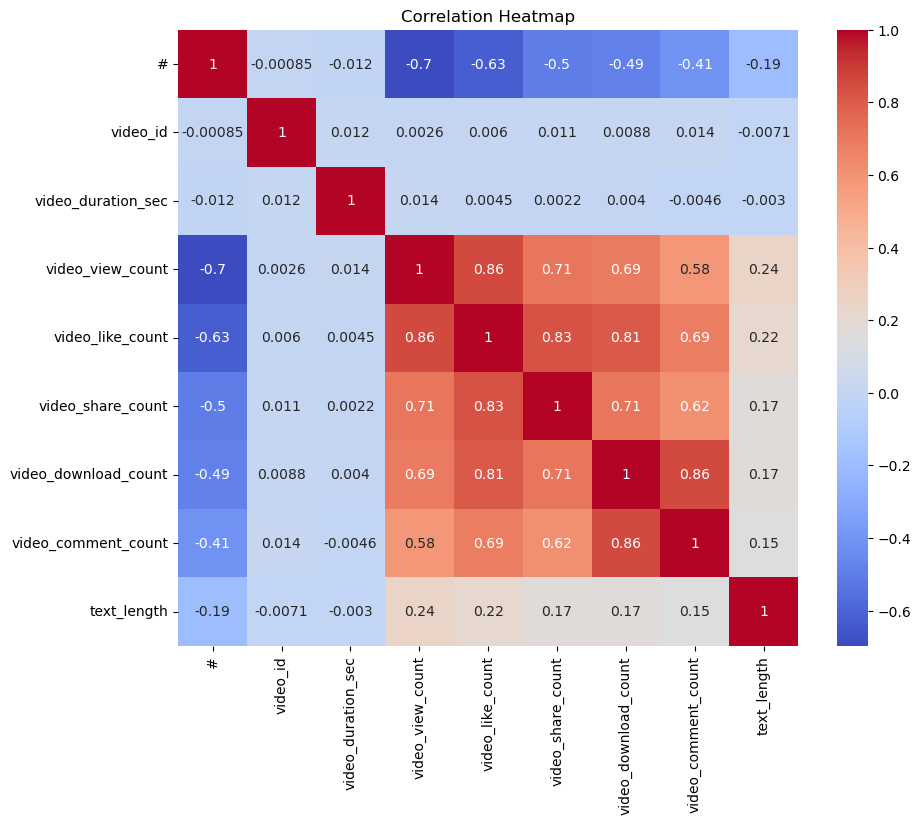

In [748]:
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


One of the model assumptions for logistic regression is no severe multicollinearity among the features. Take this into consideration as you examine the heatmap and choose which features to proceed with.

**Question:** What variables are shown to be correlated in the heatmap?

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [749]:
# Select outcome variable
y = data_upsampled['verified_status']



Select the features.


In [750]:
# Select features
x = data_upsampled[['video_duration_sec', 'claim_status', 'author_ban_status', 'video_view_count', 'video_share_count', 'video_download_count', 'video_comment_count']]


# Display first few rows of features dataframe
print(x)

       video_duration_sec claim_status author_ban_status  video_view_count  \
0                      59        claim      under review          343296.0   
1                      32        claim            active          140877.0   
2                      31        claim            active          902185.0   
3                      25        claim            active          437506.0   
4                      19        claim            active           56167.0   
...                   ...          ...               ...               ...   
35763                  42        claim            active          993273.0   
35764                  55      opinion            active            6688.0   
35765                  39      opinion            active            5009.0   
35766                  16      opinion            active             921.0   
35767                  50      opinion            active            6478.0   

       video_share_count  video_download_count  video_comment_c

### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [751]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.03, random_state=25)


Confirm that the dimensions of the training and testing sets are in alignment.

In [752]:
# Get shape of each training and testing set
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(34694, 7)
(1074, 7)
(34694,)
(1074,)


### **Task 3c. Encode variables**

Check the data types of the features.

In [753]:
# Check data types

print(x.dtypes)


video_duration_sec        int64
claim_status             object
author_ban_status        object
video_view_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
dtype: object


In [754]:
# Get unique values in `claim_status`


x_train["claim_status"].unique()

<bound method Series.unique of 3866       claim
31296    opinion
342        claim
21356    opinion
7402       claim
          ...   
35702    opinion
26767    opinion
6618       claim
24894    opinion
29828    opinion
Name: claim_status, Length: 34694, dtype: object>

In [755]:
# Get unique values in `author_ban_status`

x_train['author_ban_status'].unique()

<bound method Series.unique of 3866     under review
31296          active
342            active
21356          active
7402           active
             ...     
35702          active
26767    under review
6618           active
24894          active
29828          active
Name: author_ban_status, Length: 34694, dtype: object>

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categorical features in the training set using an appropriate method.

In [756]:
# Select the training features that needs to be encoded
features = x_train[['claim_status', 'author_ban_status']]

# Display first few rows
x_train[['claim_status', 'author_ban_status']].head()


,claim_status,author_ban_status
3866,claim,under review
31296,opinion,active
342,claim,active
21356,opinion,active
7402,claim,active


In [757]:
# Set up an encoder for one-hot encoding the categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)


In [758]:
converted_columns = encoder.fit_transform(features)
print(converted_columns)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 0.]
 ...
 [0. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [759]:
# Get feature names from encoder
names = encoder.get_feature_names_out()


In [760]:
# Display first few rows of encoded training features
converted_columns


array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [761]:
# Place encoded training features (which is currently an array) into a dataframe
X_train_encoder =  pd.DataFrame(data=converted_columns, columns=names)


# Display first few rows
X_train_encoder.head()


,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,0.0


In [762]:
# Display first few rows of `X_train` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)
x_train.drop(columns=["claim_status","author_ban_status"], inplace=True)


In [763]:
# # Concatenate `X_train` and `X_train_encoded_df` to form the final dataframe for training data (`X_train_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_train after dropping `claim_status` and `author_ban_status`,
# so that the indices align with those in `X_train_encoded_df` and `count_df`


updated_xtrain = pd.concat([x_train.drop(columns=["claim_status", "author_ban_status"], errors='ignore').reset_index(drop=True), X_train_encoder], axis=1)

# Display first few rows (changed to match the variable name created above)
updated_xtrain.head()


,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,22,550611.0,12952.0,2852.0,1710.0,0.0,0.0,1.0
1,18,3419.0,47.0,0.0,0.0,1.0,0.0,0.0
2,17,818162.0,68653.0,457.0,179.0,0.0,0.0,0.0
3,35,8271.0,107.0,7.0,1.0,1.0,0.0,0.0
4,45,673608.0,115064.0,267.0,99.0,0.0,0.0,0.0


Check the data type of the outcome variable.

In [764]:
# Get unique values of outcome variable
y.unique()


array(['not verified', 'verified'], dtype=object)

A shown above, the outcome variable is of data type `object` currently. One-hot encoding can be used to make this variable numeric.

Encode categorical values of the outcome variable the training set using an appropriate method.

In [765]:
# Set up an encoder for one-hot encoding the categorical outcome variable
y_encoder = OneHotEncoder(drop='first', sparse_output=False)


In [766]:
# Encode the training outcome variable
# Notes:
#   - Adjusting the shape of `y_train` before passing into `.fit_transform()`, since it takes in 2D array
#   - Using `.ravel()` to flatten the array returned by `.fit_transform()`, so that it can be used later to train the model
updated_ytrain = y_encoder.fit_transform(y_train.values.reshape(-1,1)).ravel()

# Display the encoded training outcome variable
updated_ytrain


array([0., 1., 0., ..., 0., 1., 1.])

### **Task 3d. Model building**

Construct a model and fit it to the training set.

In [767]:
# Scale the training and testing sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(updated_xtrain)
X_test_scaled = scaler.transform(updated_x_test)

# Fit Logistic Regression on SCALED data with balanced class weights
clf = LogisticRegression(class_weight="balanced", random_state=0, max_iter=1000)
clf.fit(X_train_scaled, updated_ytrain)


<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Taks 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

In [768]:
# Select the testing features that needs to be encoded
x_test_to_encoder= x_test[['claim_status', 'author_ban_status']]

# Display first few rows
x_test_to_encoder

,claim_status,author_ban_status
35008,opinion,active
35229,opinion,active
14822,opinion,active
29009,opinion,active
25085,opinion,active
...,...,...
10538,opinion,active
29146,opinion,active
14309,opinion,under review
3693,claim,banned


In [769]:
# Transform the testing features using the encoder
x_test_encoding = encoder.transform(x_test_to_encoder)


# Display first few rows of encoded testing features
x_test_encoding




array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [770]:
# Place encoded testing features (which is currently an array) into a dataframe
X_test_encoder = pd.DataFrame(data=x_test_encoding, columns=encoder.get_feature_names_out())


# Display first few rows

X_test_encoder.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [771]:
# Display first few rows of `X_test` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)
x_test.head()


,video_duration_sec,claim_status,author_ban_status,video_view_count,video_share_count,video_download_count,video_comment_count
35008,39,opinion,active,8560.0,45.0,1.0,0.0
35229,7,opinion,active,852.0,71.0,7.0,2.0
14822,33,opinion,active,114.0,1.0,0.0,0.0
29009,26,opinion,active,2581.0,93.0,6.0,1.0
25085,57,opinion,active,7628.0,134.0,9.0,2.0


In [772]:
# Concatenate `X_test` and `X_test_encoded_df` to form the final dataframe for training data (`X_test_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_test after dropping `claim_status`, and `author_ban_status`,
# so that the indices align with those in `X_test_encoded_df` and `test_count_df`
updated_x_test = pd.concat([x_test.drop(columns=['claim_status', 'author_ban_status'], errors='ignore').reset_index(drop=True), X_test_encoder], axis=1)


# Display first few rows
updated_x_test


,video_duration_sec,video_view_count,video_share_count,video_download_count,video_comment_count,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,39,8560.0,45.0,1.0,0.0,1.0,0.0,0.0
1,7,852.0,71.0,7.0,2.0,1.0,0.0,0.0
2,33,114.0,1.0,0.0,0.0,1.0,0.0,0.0
3,26,2581.0,93.0,6.0,1.0,1.0,0.0,0.0
4,57,7628.0,134.0,9.0,2.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1069,13,193.0,0.0,0.0,0.0,1.0,0.0,0.0
1070,26,3798.0,239.0,1.0,0.0,1.0,0.0,0.0
1071,60,4173.0,148.0,33.0,11.0,1.0,0.0,1.0
1072,33,315726.0,905.0,16.0,3.0,0.0,1.0,0.0


In [773]:
# Instantiate the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(updated_xtrain)
X_test_scaled = scaler.transform(updated_x_test)


Test the logistic regression model. Use the model to make predictions on the encoded testing set.

In [774]:
y_predict = clf.predict(X_test_scaled)


Display the predictions on the encoded testing set.

In [775]:
# Display the predictions on the encoded testing set
y_predict


array([1., 1., 1., ..., 1., 0., 0.])

Display the true labels of the testing set.

In [776]:
# Display the true labels of the testing set
y_test



35008        verified
35229        verified
14822    not verified
29009        verified
25085        verified
             ...     
10538    not verified
29146        verified
14309    not verified
3693     not verified
8639     not verified
Name: verified_status, Length: 1074, dtype: object

Encode the true labels of the testing set so it can be compared to the predictions.

In [777]:
# Encode the testing outcome variable
# Notes:
#   - Adjusting the shape of `y_test` before passing into `.transform()`, since it takes in 2D array
#   - Using `.ravel()` to flatten the array returned by `.transform()`, so that it can be used later to compare with predictions
updated_y_test= y_encoder.transform(y_test.values.reshape(-1,1)).ravel()


# Display the encoded testing outcome variable
updated_y_test

array([1., 1., 0., ..., 0., 0., 0.])

Confirm again that the dimensions of the training and testing sets are in alignment since additional features were added.

In [778]:
# Get shape of each training and testing set
updated_xtrain.shape, updated_ytrain.shape, updated_x_test.shape, updated_y_test.shape


((34694, 8), (34694,), (1074, 8), (1074,))

### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

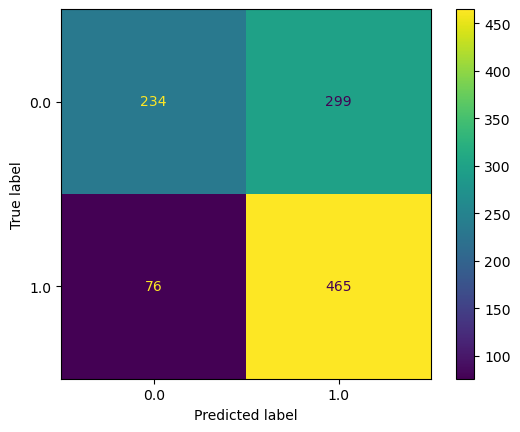

In [779]:
# Compute values for confusion matrix
cm = matrics.confusion_matrix(updated_y_test, y_predict, labels=clf.classes_)

# Create display of confusion matrix
cm_display = matrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

# Plot confusion matrix
cm_display.plot()

# Display plot
plt.show()

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [780]:
target_labels = ["not verified", "verified"]
print(classification_report(updated_y_test, y_predict, target_names=target_labels))


              precision    recall  f1-score   support

    verified       0.75      0.44      0.56       533
  unverified       0.61      0.86      0.71       541

    accuracy                           0.65      1074
   macro avg       0.68      0.65      0.63      1074
weighted avg       0.68      0.65      0.63      1074



The classification report shows that the precision and recall for 'not verified' accounts are 61% and 86%, respectively, and the accuracy is 65%. Since 'not verified' status is the target that our model predict, we specifically focused on it. Still, verified status have it own precision and recall, and the weighted average is a combination of verified and unverified evaluation metrics.

### **Task 4c. Interpret model coefficients**

In [781]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
# Place into a DataFrame for readability
pd.DataFrame(data={"Feature Name":clf.feature_names_in_, "Model Coefficient":clf.coef_[0]})






,Feature Name,Model Coefficient
0,video_duration_sec,8.478038e-03
1,video_view_count,-2.290788e-06
2,video_share_count,5.738351e-06
3,video_download_count,-2.083726e-04
4,video_comment_count,3.796573e-04
5,claim_status_opinion,3.733743e-04
6,author_ban_status_banned,-1.465715e-05
7,author_ban_status_under review,4.770223e-07


### **Task 4d. Conclusion**

1. What are the key takeaways from this project?

2. What results can be presented from this project?

The main takeaways from this lab is the following:

- Data balance and multicollinearity should be checked before building the model, as they can lead to inaccurate model predictions. In this case, we dropped the video_like_count column because it had the highest correlation with other independent variables (video features), which could skew the results.

- The confusion matrix reflects that the model predicts 43.3% of the verified accounts that were actually verified and 21.8% were predicted as being not verified that are actually unverified. However, 27.8% were predicted as being unverified despite being verified and 7% were predicted as verified despite being unverified.

- The model's precision of 61% for 'unverified' accounts is less than ideal, but the recall of 86% is very good. The overall accuracy of 65% is lower than what is generally considered acceptable.
- 
- Based on the logistic regression model: for every additional second in the video duration, the log odds that the account is verified increase by 0.008.

This logistic regression model is built to predict the status of an account based on video features. The estimated model coefficients show that video_duration_sec has the highest correlation with the account status: longer videos are highly correlated with verified accounts. Other features have small coefficients, which means they have a small association with the account status.



**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 